<h1 style="font-size:20px; font-family: Verdana;">ALZHEIMER DESEASE BINARY CLASSIFICATION</h1>


In [8]:
import torch
print(f"Versione PyTorch: {torch.__version__}")
print(f"CUDA disponibile? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU rilevata: {torch.cuda.get_device_name(0)}")
else:
    print("ATTENZIONE: PyTorch non vede la GPU!")

Versione PyTorch: 2.5.1+cu121
CUDA disponibile? True
GPU rilevata: NVIDIA GeForce RTX 4090


1. LIBRARIES

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn.functional as F
import nibabel as nib
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

2. LOADING DATASET AND CHOOSING THE CLASSES

In [10]:
#loading the dataset
with open("Dataset_Edin.pkl", "rb") as f:
    data_dict=pickle.load(f)

In [11]:
#filtering class 0 e 2
#creating a mask to choose only the index where the label is 0 or 2

X_fa_raw=np.array(data_dict['FA'])
X_md_raw=np.array(data_dict['MD'])
y_raw=np.array(data_dict['Labels'])

#filtering class 0 e 2
#creating a mask to choose only the index where the label is 0 or 2
mask=(y_raw==0) | (y_raw==2)
X_fa=X_fa_raw[mask]
X_md=X_md_raw[mask]
y=y_raw[mask]

#trasforming class 2 in class 1 for binary classification
y[y==2]=1

print(f"Nuovo dataset: {len(y)} campioni")
print(f"Classe 0 Sani: {np.sum(y==0)} | Classe 1 (Alzheimer): {np.sum(y==1)}")

Nuovo dataset: 317 campioni
Classe 0 Sani: 185 | Classe 1 (Alzheimer): 132


In [ ]:
class AlzheimerDataset(Dataset):
    def __init__(self, fa_data, md_data, labels, target_shape=(64, 64, 64)):
        """
        fa_data: Array NumPy con tutti i volumi FA
        md_data: Array NumPy con tutti i volumi MD
        labels: Lista o array con le etichette
        """
        self.fa_data = fa_data
        self.md_data = md_data
        self.labels = labels
        self.target_shape = target_shape

    def __len__(self):
        return len(self.labels)

    def normalize(self, data):
        dmin, dmax = data.min(), data.max()
        if dmax - dmin > 0:
            return (data - dmin) / (dmax - dmin)
        return data

    #TOGLIEREEEE-->DISTORCE IL CERVELLO E NON PERMETTE UNA CORRETTA INTERPRETAZIONE E CLASSIFICAZIONE
    #def resize_volume(self, img_data):
        # Aggiungiamo dimensioni per PyTorch: [1, 1, D, H, W]
        #img_tensor = torch.from_numpy(img_data).float().unsqueeze(0).unsqueeze(0)
        #resized = F.interpolate(img_tensor, size=self.target_shape, mode='trilinear', align_corners=False)
        #return resized.squeeze(0) # Ritorna [1, D, H, W]

    def __getitem__(self, idx):
        # Prendiamo il volume direttamente dall'array in memoria
        fa_vol = self.fa_data[idx]
        md_vol = self.md_data[idx]

        # Normalizzazione e Ridimensionamento
        fa_norm = self.resize_volume(self.normalize(np.nan_to_num(fa_vol)))
        md_norm = self.resize_volume(self.normalize(np.nan_to_num(md_vol)))

        # Concatenazione canali: [2, 64, 64, 64]
        x = torch.cat([fa_norm, md_norm], dim=0)
        y_label = torch.tensor(self.labels[idx], dtype=torch.long)

        return x, y_label


3. ARCHITECTURE OF THE 3D CNN

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AlzheimerCNN3D(nn.Module):
    def __init__(self, num_classes=2):
        super(AlzheimerCNN3D, self).__init__()
        
        # 1. ESTRAZIONE CARATTERISTICHE (Blocchi Convoluzionali)
        self.features = nn.Sequential(
            # Primo blocco-->analisi spaizale ampia
            nn.Conv3d(2, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2),
            
            # Secondo blocco-->analisi intermedia
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            #ANCHE NO ALL'INIZIO, mi aiuta ad arrivare alla convergenza prima ma non è sempre utile
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(2),
            
            # Terzo blocco-->analisi profonda
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.MaxPool3d(2),

            # Quarto blocco-->alta astrazione
            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(),
        )
        
        # 2. GLOBAL AVERAGE POOLING--PUO' essere utile come no, altrimenti utilizza un laver
        #e poi fai un flat. Ultimo tensore (30x256)-->con flat vettorizzo tutto
        # Riduce qualsiasi dimensione di input a (1, 1, 1) per ogni canale
        self.gap = nn.AdaptiveAvgPool3d(1)
        
        # 3. CLASSIFICATORE (Molto più leggero!)
        # L'input qui è 128 (il numero di canali dell'ultima conv)
        self.classifier = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)   # Estrae le mappe (Batch, 128, 8, 8, 8)
        x = self.gap(x)    #output [Batch, 128, 1, 1, 1]
        x = torch.flatten(x, 1) # Diventa un vettore di 128 elementi
        x = self.classifier(x) # Decide se Sano o AD
        return x

4. TRAINING FUNCTION

In [14]:
# 4. FUNZIONI DI TRAINING
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        #usa le funzioni che ci sono già per f1 score ecc
        

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss/len(loader), 100.*correct/total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long().view(-1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss/len(loader), 100.*correct/total

5. CROSS-VALIDATION

In [15]:
epochs = 100
learning_rate = 1e-4
k_folds = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
fold_results = []

for fold, (train_ids, val_ids) in enumerate(skf.split(X_fa, y)):
    print(f"\n--- INIZIO FOLD {fold + 1}/{k_folds} (BINARIO: 0 vs 2) ---")
    print("Training in corso", end="")

    train_ds = AlzheimerDataset(X_fa[train_ids], X_md[train_ids], y[train_ids])
    val_ds = AlzheimerDataset(X_fa[val_ids], X_md[val_ids], y[val_ids])
    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, drop_last=False)
    
    model = AlzheimerCNN3D(num_classes=2).to(device)


    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.1)

    scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.2, patience=10)

    #la somma deve essere 1-->ragiona in termini percentuali e assegni i pesi in quel modo
    class_weights=torch.tensor([1.0, 1.8]).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    
    best_val_loss = float('inf') 
    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)


        #aggiornamento scheduler basato su validation loss
        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss=val_loss

            #salva anche validation della fold, cosi hai tutto li

            torch.save(model.state_dict(), f'best_binary_model_fold{fold+1}.pth')
            #print(f"[Modello salvato al minimo di Loss: {val:loss:.4f}]")

            
        if (epoch + 1) % 10 == 0:
            print(f"\nFold {fold+1} | Epoca {epoch+1:02d}: T-Loss: {train_loss:.3f} | T-Acc: {train_acc:.1f}% | V-Loss: {val_loss:.3f} | V-Acc: {val_acc:.1f}%")
            if (epoch + 1) < epochs: print("Continua", end="")
        elif (epoch + 1) % 2 == 0:
            print(".", end="", flush=True)
        
    fold_results.append(best_val_acc)
    print(f"\n Fine Fold {fold+1}. Miglior Val Acc registrata: {best_val_acc:.2f}%")


--- INIZIO FOLD 1/5 (BINARIO: 0 vs 2) ---
Training in corso

AttributeError: 'AlzheimerDataset' object has no attribute 'resize_volume'

In [ ]:
#DEVI FARE I GRAFICI DI LOSS E ACC PER VALIDATIN E TRAIN
#FAI LA MEDIA LUNGO LE FOLD E POI TI CALCOLI STD DEV, OPPURE CONFIDENCE INTERVAL
#L'OMBRA NEL GRAFICO MI DEVE RAPPRESENTARE LA STD DEV, QUESTO PERCHè SE HO UN GRAFICO IN CUI VEDO LA STD DEV CHE VADA A ZIGZAG SIGNIFICA
#CHE QUALCOSA NON VA

6. FINAL REPORT

In [ ]:
epochs = 100
learning_rate = 1e-4
k_folds = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
fold_results = []

for fold, (train_ids, val_ids) in enumerate(skf.split(X_fa, y)):
    print(f"\n--- INIZIO FOLD {fold + 1}/{k_folds} (BINARIO: 0 vs 2) ---")
    print("Training in corso", end="")

    train_ds = AlzheimerDataset(X_fa[train_ids], X_md[train_ids], y[train_ids])
    val_ds = AlzheimerDataset(X_fa[val_ids], X_md[val_ids], y[val_ids])
    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, drop_last=False)
    
    model = AlzheimerCNN3D(num_classes=2).to(device)


    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.1)

    scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.2, patience=10)

    #la somma deve essere 1-->ragiona in termini percentuali e assegni i pesi in quel modo
    class_weights=torch.tensor([1.0, 1.8]).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    
    best_val_loss = float('inf') 
    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)


        #aggiornamento scheduler basato su validation loss
        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss=val_loss

            #salva anche validation della fold, cosi hai tutto li

            torch.save(model.state_dict(), f'best_binary_model_fold{fold+1}.pth')
            #print(f"[Modello salvato al minimo di Loss: {val:loss:.4f}]")

            
        if (epoch + 1) % 10 == 0:
            print(f"\nFold {fold+1} | Epoca {epoch+1:02d}: T-Loss: {train_loss:.3f} | T-Acc: {train_acc:.1f}% | V-Loss: {val_loss:.3f} | V-Acc: {val_acc:.1f}%")
            if (epoch + 1) < epochs: print("Continua", end="")
        elif (epoch + 1) % 2 == 0:
            print(".", end="", flush=True)
        
    fold_results.append(best_val_acc)
    print(f"\n Fine Fold {fold+1}. Miglior Val Acc registrata: {best_val_acc:.2f}%")


########################################
RISULTATI FINALI BINARI (Sani vs Alzheimer)
Accuracy per ogni fold: [59.38, 62.5, 71.43, 66.67, 65.08]
ACCURATEZZA MEDIA: 65.01%
########################################


7. CONFUSION MATRIX

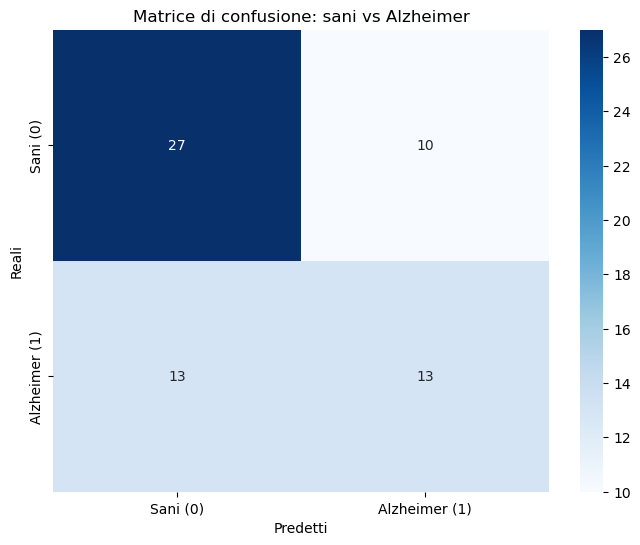

In [ ]:
def plot_confusion_matrix(model, loader, device):
    model.eval()
    all_preds=[]
    all_labels=[]

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels=inputs.to(device), labels.to(device)
            outputs=model(inputs)
            _, predicted=outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    #calculating the matrix
    cm=confusion_matrix(all_labels, all_preds)

    #graphical visualization
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Sani (0)","Alzheimer (1)"],
                yticklabels=["Sani (0)", "Alzheimer (1)"])
    plt.xlabel('Predetti')
    plt.ylabel('Reali')
    plt.title("Matrice di confusione: sani vs Alzheimer")
    plt.show()

plot_confusion_matrix(model, val_loader, device)

In [ ]:

def generate_final_text_report(X, y, device):
    all_preds = []
    all_labels = []
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    print("Recupero dati dai fold per la matrice...")
    
    for fold, (_, val_ids) in enumerate(skf.split(X, y)):
        # 1. Carica il modello migliore di questo fold
        model = AlzheimerCNN3D(num_classes=2).to(device)
        model.load_state_dict(torch.load(f'best_binary_model_fold{fold+1}.pth'))
        model.eval()
        
        # 2. Prepara i dati di validazione
        val_ds = AlzheimerDataset(X[val_ids], X_md[val_ids], y[val_ids])
        val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)
        
        # 3. Predizione
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs.to(device))
                _, predicted = outputs.max(1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())

    # --- CALCOLO MATRICE TESTUALE ---
    cm = confusion_matrix(all_labels, all_preds)
    
    print("\n" + "="*40)
    print("      MATRICE DI CONFUSIONE FINALE")
    print("="*40)
    print(f"{'':<15} | Pred Sano | Pred AD")
    print("-" * 40)
    print(f"{'Reale Sano (0)':<15} | {cm[0][0]:^9} | {cm[0][1]:^8}")
    print(f"{'Reale AD (1)':<15} | {cm[1][0]:^9} | {cm[1][1]:^8}")
    print("="*40)

    # Report metriche (Precision, Recall, F1)
    print("\nREPORT DI CLASSIFICAZIONE:")
    print(classification_report(all_labels, all_preds, target_names=['Sano', 'AD']))
    
    return cm # Restituisce la matrice se serve per altri calcoli

generate_final_text_report(X_fa, y, device)

Recupero dati dai fold per la matrice...


/tmp/ipykernel_167181/1980901151.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_binary_model_fold{fold+1}.pth'))



      MATRICE DI CONFUSIONE FINALE
                | Pred Sano | Pred AD
----------------------------------------
Reale Sano (0)  |    146    |    39   
Reale AD (1)    |    72     |    60   

REPORT DI CLASSIFICAZIONE:
              precision    recall  f1-score   support

        Sano       0.67      0.79      0.72       185
          AD       0.61      0.45      0.52       132

    accuracy                           0.65       317
   macro avg       0.64      0.62      0.62       317
weighted avg       0.64      0.65      0.64       317



array([[146,  39],
       [ 72,  60]])

In [ ]:
#CALCOLA PER OGNI EPOCH LE METRICHE
#METTILE IN UN DIZIONARIO, CALCOLI IL VALORE MEDIO LUNGO LE RIGHE
#ALL'INTERNO DELLE MATRICI CHE CONTENGONO LA GRANDE QUANTITà DI VALORI
#DEVI FARE LA MEDIA LUNGO LE RIGHE, OTTENENGO COSI UNA SOLA RIGA IN FUNZIONE DEL TEMPO
#DA SOLA LA MEDIA NON E INFORMATIVA, CALCOLO LA STD DEV LUNGO OGNI RIGA
#ALLA FINE FAI DI NUOVO I DUE PLOT, UNO PER LOSS E UNO PER ACC
#E